<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/AU_v1_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: 21574 rows, 38 columns.
Feature Matrix Shape: (21574, 35)
Binary Target Classes: ['Benign' 'Malware']

================ BINARY EVALUATION METRICS ================
Overall Accuracy: 99.40%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign     0.9963    0.9916    0.9940      2154
     Malware     0.9917    0.9963    0.9940      2161

    accuracy                         0.9940      4315
   macro avg     0.9940    0.9940    0.9940      4315
weighted avg     0.9940    0.9940    0.9940      4315



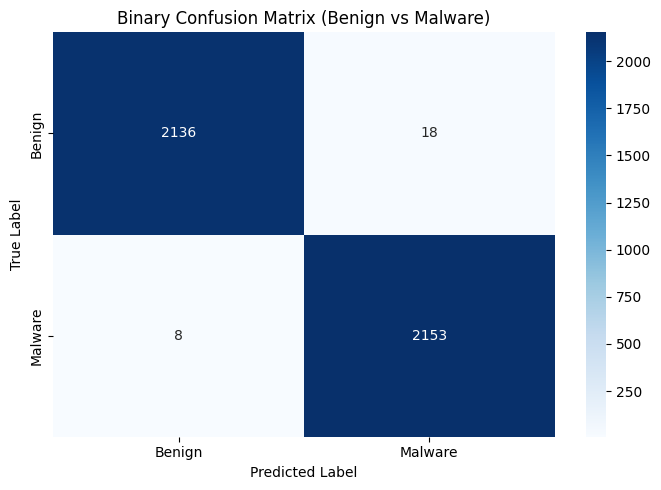

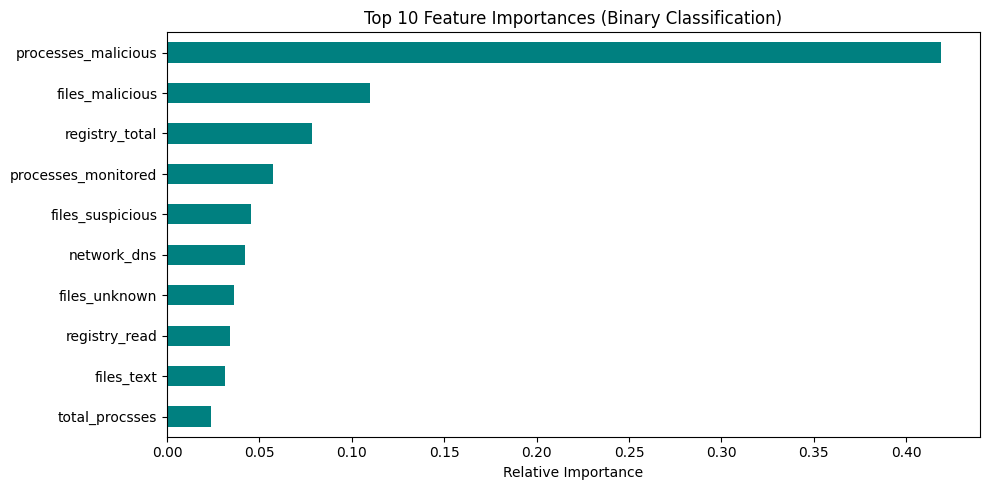

In [2]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

cleaned_file = "AU-PEMal-2025-V1_Cleaned.csv"

# ---------------------------------------------------------
# 1. Dataset Resolution & Cleaning
# ---------------------------------------------------------
if not os.path.exists(cleaned_file):
    print(f"'{cleaned_file}' not found. Checking for raw dataset...")
    raw_files = [
        f for f in glob.glob("AU-PEMal-2025-V1*.csv") if "Cleaned" not in f
    ]

    if raw_files:
        raw_file = raw_files[0]
        print(f"Found existing raw file: '{raw_file}'")
    else:
        print("Please upload 'AU-PEMal-2025-V1.csv':")
        uploaded = files.upload()
        raw_file = list(uploaded.keys())[0]

    # Preprocess and clean raw dataset
    print(f"Cleaning '{raw_file}'...")
    df_raw = pd.read_csv(raw_file)

    # Drop non-predictive hash/identifier columns
    non_feature_cols = [
        "sha1",
        "Name",
        "filename",
        "Raw_filename",
        "hash",
        "md5",
    ]
    cols_to_drop = [c for c in non_feature_cols if c in df_raw.columns]
    if cols_to_drop:
        df_raw = df_raw.drop(columns=cols_to_drop)

    hex_cols = [
        "EntryPoint",
        "SizeOfCode",
        "SizeOfImage",
        "SizeOfInitializedData",
        "SizeOfUninitializedData",
        "rdata_VirtualSize",
        "rdata_VirtualAddress",
        "rdata_SizeOfRawData",
        "rdata_PointerToRawData",
        "text_VirtualSize",
        "text_SizeOfRawData",
        "text_PointerToRawData",
        "BaseOfCode",
        "BaseOfData",
        "ImageBase",
        "Checksum",
        "SectionAlignment",
        "SizeOfHeaders",
    ]

    def parse_hex_to_int(val):
        if pd.isna(val):
            return 0
        val_str = str(val).strip()
        try:
            if val_str.lower().startswith("0x"):
                return int(val_str, 16)
            else:
                return int(float(val_str))
        except Exception:
            return 0

    for col in hex_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].apply(parse_hex_to_int)

    df_clean = df_raw.drop_duplicates(keep="first").dropna()
    df_clean.to_csv(cleaned_file, index=False)
    print(
        f"Saved '{cleaned_file}' ({df_clean.shape[0]} rows, {df_clean.shape[1]} columns)."
    )

# ---------------------------------------------------------
# 2. Load Dataset & Enforce Binary Target (Benign vs Malware)
# ---------------------------------------------------------
df = pd.read_csv(cleaned_file)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

# Enforce binary target selection
if "Class" in df.columns:
    binary_target = df["Class"].copy()
elif "Category" in df.columns:
    # Map Category to binary if 'Class' is absent
    binary_target = df["Category"].apply(
        lambda x: "Benign" if str(x).lower() == "benign" else "Malware"
    )
elif "Family" in df.columns:
    # Map Family to binary if 'Class' is absent
    binary_target = df["Family"].apply(
        lambda x: "Benign" if str(x).lower() == "benign" else "Malware"
    )
else:
    raise ValueError("No valid class or category column found for binary classification.")

# Standardize binary labels to explicit string names ('Benign', 'Malware')
def standardize_label(val):
    val_str = str(val).strip().lower()
    if val_str in ["0", "benign", "goodware"]:
        return "Benign"
    return "Malware"

y_binary = binary_target.apply(standardize_label)

# Encode binary target (Benign -> 0, Malware -> 1)
le = LabelEncoder()
y = le.fit_transform(y_binary)

# Drop all label/category columns from feature matrix X
all_target_labels = ["Class", "Category", "Family", "label", "target"]
X = df.drop(columns=[c for c in all_target_labels if c in df.columns])
X = X.select_dtypes(include=[np.number])

# Drop zero-variance constant features
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)
    print(
        f"Dropped zero-variance constant columns ({len(constant_cols)}): {constant_cols}"
    )

print(f"Feature Matrix Shape: {X.shape}")
print(f"Binary Target Classes: {le.classes_}")

# ---------------------------------------------------------
# 3. Stratified Train / Test Split & Model Training
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Performance Evaluation & Classification Report
# ---------------------------------------------------------
y_pred = model.predict(X_test)
class_names = [str(c) for c in le.classes_]

acc = accuracy_score(y_test, y_pred)
print("\n================ BINARY EVALUATION METRICS ================")
print(f"Overall Accuracy: {acc * 100:.2f}%\n")
print("CLASSIFICATION REPORT:")
print(
    classification_report(y_test, y_pred, target_names=class_names, digits=4)
)

# ---------------------------------------------------------
# 5. Confusion Matrix Visualization
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Binary Confusion Matrix (Benign vs Malware)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("binary_confusion_matrix.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 6. Plot Top 10 Feature Importances
# ---------------------------------------------------------
importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances (Binary Classification)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("binary_feature_importance.png", dpi=300)
plt.show()